In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import cycle
from scipy.stats import pearsonr

In [37]:
def plot_relative_policy_cost(districts, tolerance_level, policy_order, policy_colors):
    fig, axs = plt.subplots(1, len(districts), figsize=(6 * len(districts), 6), sharex=True)

    for i, district in enumerate(districts):
        # Filter the dataframe for the specific district and tolerance level
        df = pd.read_csv("results/{}_pool=central.csv".format(district))
        filtered_df = df[(df["unconditional_tolerance"] == tolerance_level)].copy()

        # Compute the relative policy_cost compared to the "saturation" policy
        saturation_cost = filtered_df.loc[filtered_df["policy"] == "saturation", "policy_cost"].iloc[0]
        filtered_df["relative_cost"] = filtered_df["policy_cost"] / saturation_cost

        filtered_df["policy"] = pd.Categorical(filtered_df["policy"], categories=policy_order)
        filtered_df.sort_values("policy", inplace=True)

        # Make a bar graph of relative cost vs. policy
        bars = axs[i].bar(filtered_df["policy"], filtered_df["relative_cost"], color=policy_colors)
        axs[i].set_ylabel("Cost Relative to Saturation Policy")
        axs[i].set_title(f"Malawi District - {district}")
    

        # Put the relative cost values on top of each bar
        for bar, cost in zip(bars, filtered_df["relative_cost"]):
            axs[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{cost:.2f}", ha='center', va='bottom')

    plt.suptitle(f"Relative Policy Cost when Unconditional Tolerance={tolerance_level}")
    plt.savefig("figs/relative_cost_{}_uncondtol={}.pdf".format("-".join(districts), tolerance_level))


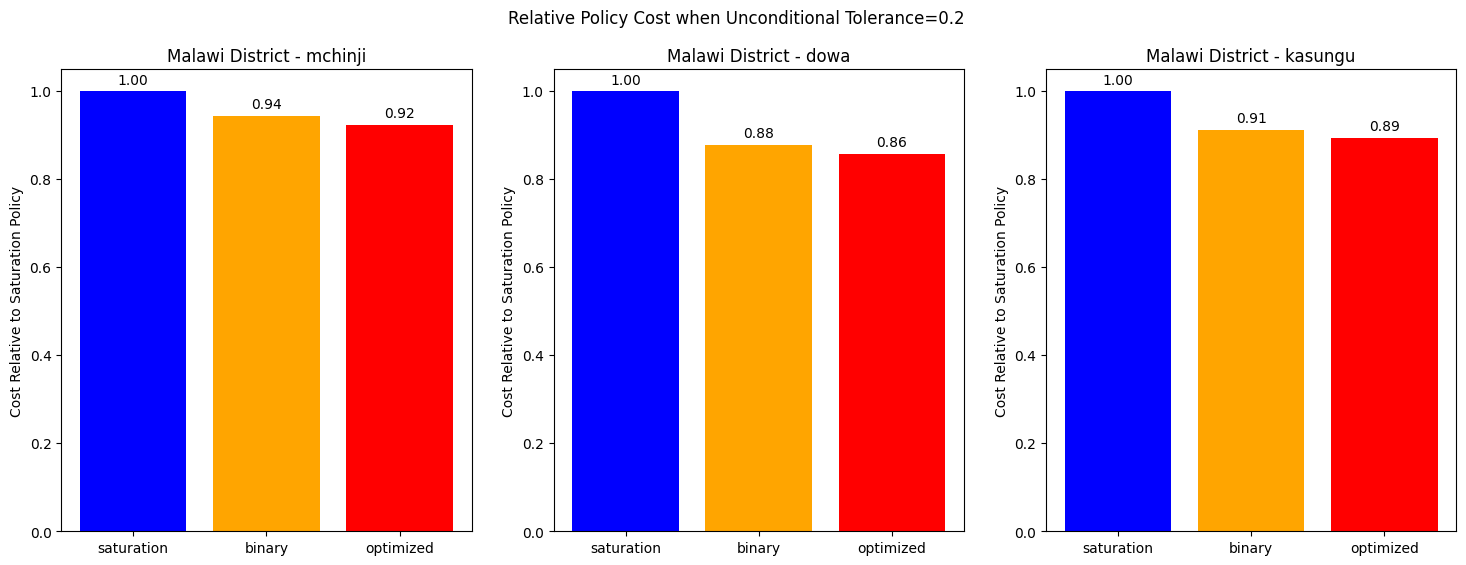

In [38]:
policy_order = ["saturation", "binary", "geographic", "optimized"]
plot_relative_policy_cost(["mchinji", "dowa", "kasungu"], 0.2, policy_order=policy_order, policy_colors=["blue", "orange", "red"])

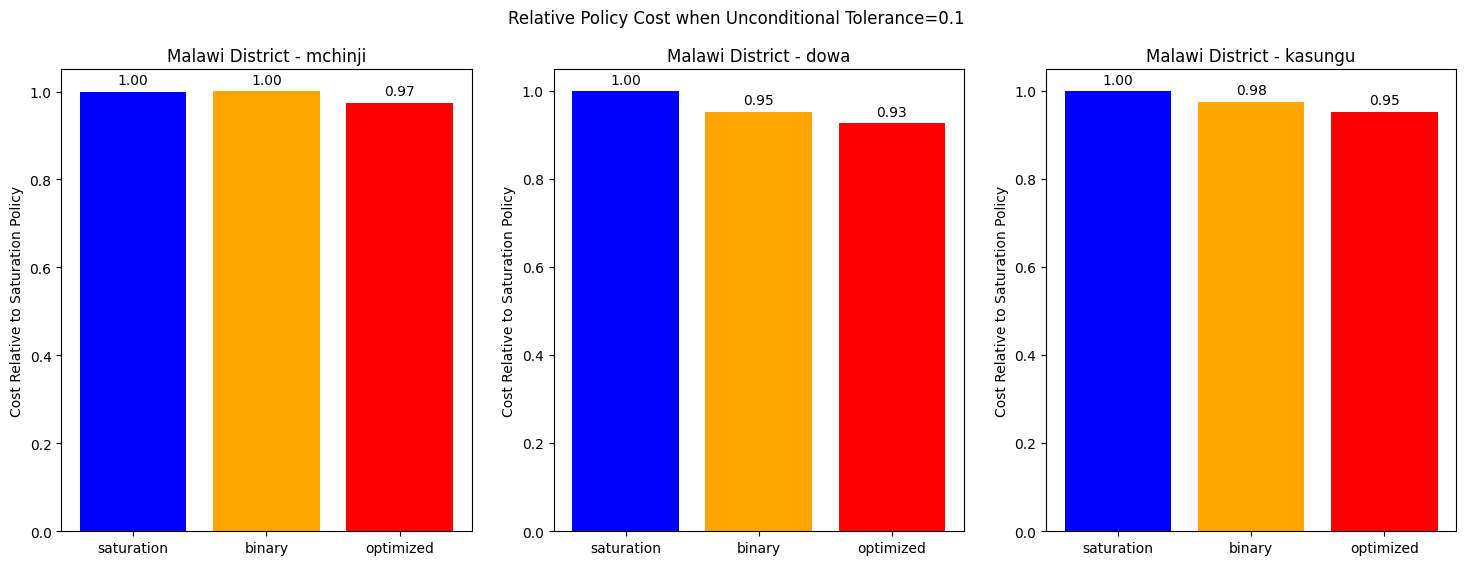

In [40]:
plot_relative_policy_cost(["mchinji", "dowa", "kasungu"], 0.1, policy_order=policy_order, policy_colors=["blue", "orange", "red"])